# Elo_Ratings

In [1]:
import os

# Move up one level to set the working directory to the repo root
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

## Process Data for Input

Dataset (expected format: `Season`, `DayNum`, `Team1`, `Team2`, `Score1`, `Score2`, `IsTournament`, `HomeTeam`)

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path

KAGGLE_DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data\kaggle")))
# SUBMISSION_DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data\submissions")))
# DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data")))

m_results_reg = pd.read_csv(KAGGLE_DATA_PATH  / "MRegularSeasonCompactResults.csv")
w_results_reg = pd.read_csv(KAGGLE_DATA_PATH  / "WRegularSeasonCompactResults.csv")

m_conf = pd.read_csv(KAGGLE_DATA_PATH  / "MConferenceTourneyGames.csv")
w_conf = pd.read_csv(KAGGLE_DATA_PATH  / "WConferenceTourneyGames.csv")

m_results_tourney = pd.read_csv(KAGGLE_DATA_PATH  / "MNCAATourneyCompactResults.csv")
w_results_tourney = pd.read_csv(KAGGLE_DATA_PATH  / "WNCAATourneyCompactResults.csv")


m_conf['game_id'] = # Season_DayNum_WTeamID_LTeamID

m_results_reg['game_id'] = # Season_ DayNum_WTeamID_LTeamID
m_results_reg['Team1'] = m_results_reg['WTeam']
m_results_reg['Team2'] = m_results_reg['LTeam']
m_results_reg['Score1'] = m_results_reg['WScore']
m_results_reg['Score2'] = m_results_reg['LScore']
m_results_reg['IsTournament'] = # if game_id in m_conf['game_id'] then 1, else 0
m_results_reg['HomeTeam'] = # if WLoc = H, then HomeTeam = Team1 elif WLoc = A, then HomeTeam = Team2

m_results_tourney['game_id'] = # Season_ DayNum_WTeamID_LTeamID
m_results_tourney['Team1'] = m_results_tourney['WTeam']
m_results_tourney['Team2'] = m_results_tourney['LTeam']
m_results_tourney['Score1'] = m_results_tourney['WScore']
m_results_tourney['Score2'] = m_results_tourney['LScore']
m_results_tourney['IsTournament'] = 1
m_results_tourney['HomeTeam'] = # if WLoc = H, then HomeTeam = Team1 elif WLoc = A, then HomeTeam = Team2


w_conf['game_id'] = # Season_DayNum_WTeamID_LTeamID

w_results_reg['game_id'] = # Season_ DayNum_WTeamID_LTeamID
w_results_reg['Team1'] = w_results_reg['WTeam']
w_results_reg['Team2'] = w_results_reg['LTeam']
w_results_reg['Score1'] = w_results_reg['WScore']
w_results_reg['Score2'] = w_results_reg['LScore']
w_results_reg['IsTournament'] = # if game_id in w_conf['game_id'] then 1, else 0
w_results_reg['HomeTeam'] = # if WLoc = H, then HomeTeam = Team1 elif WLoc = A, then HomeTeam = Team2

w_results_tourney['game_id'] = # Season_DayNum_WTeamID_LTeamID
w_results_tourney['Team1'] = w_results_tourney['WTeam']
w_results_tourney['Team2'] = w_results_tourney['LTeam']
w_results_tourney['Score1'] = w_results_tourney['WScore']
w_results_tourney['Score2'] = w_results_tourney['LScore']
w_results_tourney['IsTournament'] = 1
w_results_tourney['HomeTeam'] = # if WLoc = H, then HomeTeam = Team1 elif WLoc = A, then HomeTeam = Team2



In [43]:
import os
import pandas as pd
from pathlib import Path

KAGGLE_DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data/kaggle")))

def make_game_data():
    """Loads and processes NCAA basketball game data from Kaggle sources,
    merging men's and women's regular season, conference tournament, and NCAA tournament results
    into a single DataFrame.

    Returns:
        pd.DataFrame: Combined game dataset with standardized fields.
    """

    # Load datasets
    m_results_reg = pd.read_csv(KAGGLE_DATA_PATH / "MRegularSeasonCompactResults.csv")
    w_results_reg = pd.read_csv(KAGGLE_DATA_PATH / "WRegularSeasonCompactResults.csv")

    m_conf = pd.read_csv(KAGGLE_DATA_PATH / "MConferenceTourneyGames.csv")
    w_conf = pd.read_csv(KAGGLE_DATA_PATH / "WConferenceTourneyGames.csv")

    m_results_tourney = pd.read_csv(KAGGLE_DATA_PATH / "MNCAATourneyCompactResults.csv")
    w_results_tourney = pd.read_csv(KAGGLE_DATA_PATH / "WNCAATourneyCompactResults.csv")

    # Function to process datasets (regular season and tournament)
    def process_results(results_df, conf_df, gender, stage_tourney=2):
        """Processes a DataFrame of game results to standardize columns and assign stages."""
        if results_df.empty:
            return None  # Skip empty DataFrames

        results_df["gender"] = gender
        results_df["game_id"] = results_df.apply(lambda row: f"{row.Season}_{row.DayNum}_{row.WTeamID}_{row.LTeamID}", axis=1)
        
        # Define team assignments
        results_df["Team1"] = results_df["WTeamID"]
        results_df["Team2"] = results_df["LTeamID"]
        results_df["Score1"] = results_df["WScore"]
        results_df["Score2"] = results_df["LScore"]

        # Assign stage: 0 = Regular Season, 1 = Conference Tournament, 2 = NCAA Tournament
        conf_game_ids = set(conf_df.apply(lambda row: f"{row.Season}_{row.DayNum}_{row.WTeamID}_{row.LTeamID}", axis=1))
        results_df["Stage"] = results_df["game_id"].apply(lambda x: 1 if x in conf_game_ids else stage_tourney)
        
        # Determine home team based on location
        def assign_home_team(row):
            if row.WLoc == "H":
                return row.Team1
            elif row.WLoc == "A":
                return row.Team2
            return None  # Neutral site

        results_df["HomeTeam"] = results_df.apply(assign_home_team, axis=1)

        return results_df[["Season", "DayNum", "game_id", "gender", "Team1", "Team2", "Score1", "Score2", "Stage", "HomeTeam"]]

    # Process data
    processed_dfs = [
        process_results(m_results_reg, m_conf, "Men", 0),
        process_results(w_results_reg, w_conf, "Women", 0),
        process_results(m_results_tourney, m_conf, "Men"),
        process_results(w_results_tourney, w_conf, "Women"),
    ]

    # Remove None values (empty DataFrames) before concatenation
    processed_dfs = [df for df in processed_dfs if df is not None and not df.empty]

    # Concatenate only non-empty DataFrames
    final_df = pd.concat(processed_dfs, ignore_index=True) if processed_dfs else pd.DataFrame()

    return final_df


In [44]:
game_data_df = make_game_data()

C:\Users\brown\AppData\Local\Temp\ipykernel_33276\913849717.py:69: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat(processed_dfs, ignore_index=True) if processed_dfs else pd.DataFrame()


In [45]:
game_data_df.head()

,Season,DayNum,game_id,gender,Team1,Team2,Score1,Score2,Stage,HomeTeam
0,1985,20,1985_20_1228_1328,Men,1228,1328,81,64,0,NaN
1,1985,25,1985_25_1106_1354,Men,1106,1354,77,70,0,1106.0
2,1985,25,1985_25_1112_1223,Men,1112,1223,63,56,0,1112.0
3,1985,25,1985_25_1165_1432,Men,1165,1432,70,54,0,1165.0
4,1985,25,1985_25_1192_1447,Men,1192,1447,86,74,0,1192.0


## Optimizing K-factor

Evaluating K = 10 ...
Evaluating K = 20 ...
Evaluating K = 30 ...
Evaluating K = 40 ...
Evaluating K = 50 ...
Evaluating K = 60 ...
Evaluating K = 70 ...
Evaluating K = 80 ...
Evaluating K = 10 ...
Evaluating K = 20 ...
Evaluating K = 30 ...
Evaluating K = 40 ...
Evaluating K = 50 ...
Evaluating K = 60 ...
Evaluating K = 70 ...
Evaluating K = 80 ...
Evaluating K = 40 ...
Evaluating K = 50 ...
Evaluating K = 60 ...
Evaluating K = 70 ...
Evaluating K = 80 ...
Evaluating K = 90 ...
Evaluating K = 100 ...
Evaluating K = 110 ...
Evaluating K = 120 ...
Evaluating K = 40 ...
Evaluating K = 50 ...
Evaluating K = 60 ...
Evaluating K = 70 ...
Evaluating K = 80 ...
Evaluating K = 90 ...
Evaluating K = 100 ...
Evaluating K = 110 ...
Evaluating K = 120 ...


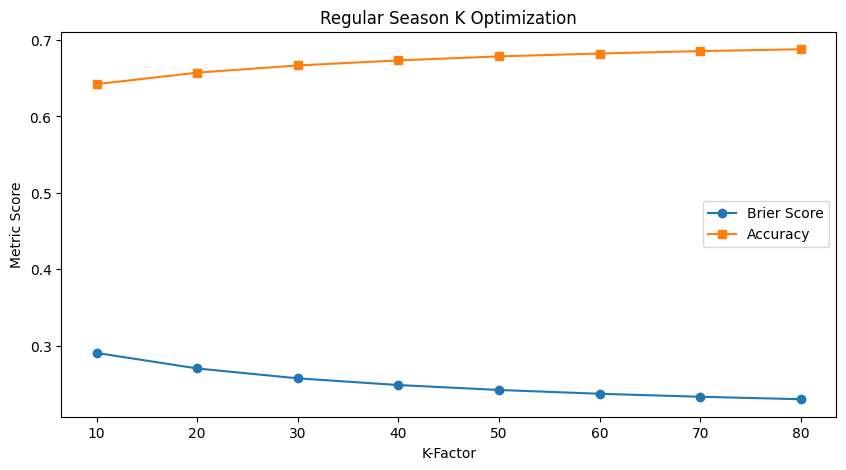

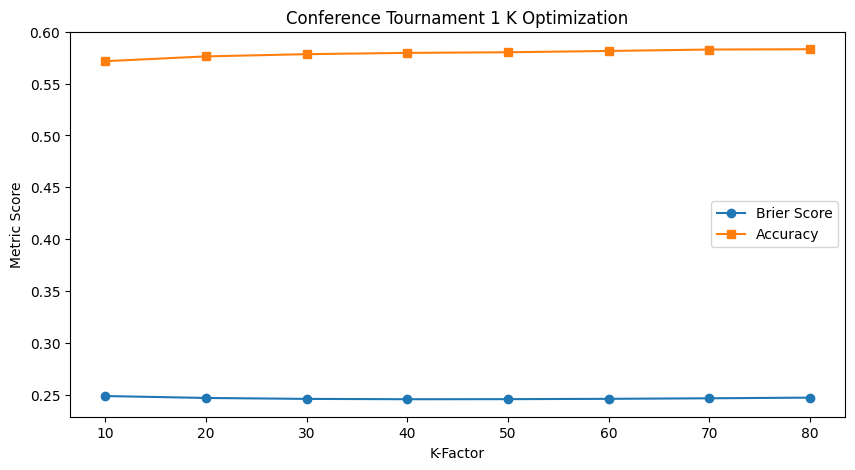

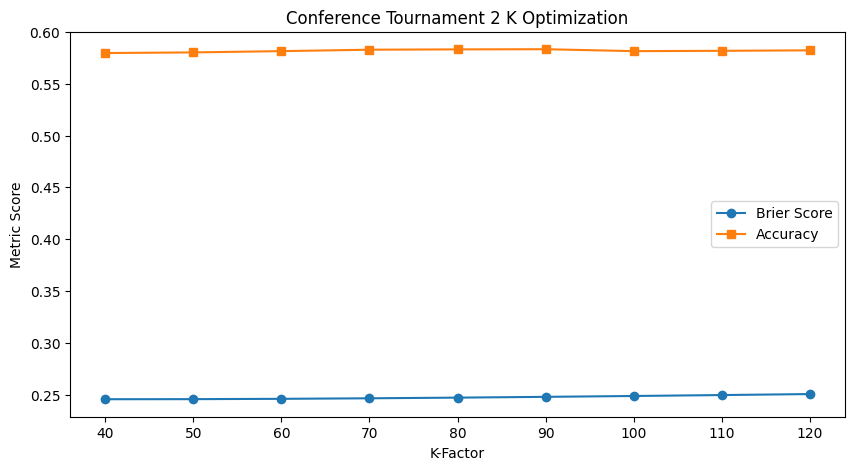

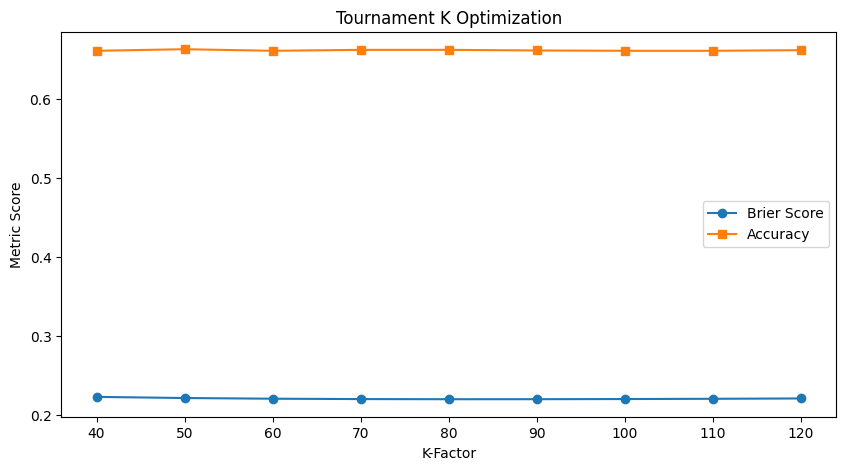

Best Regular Season K: K              80.000000
Brier Score     0.230097
MSE             0.230097
Accuracy        0.687988
Name: 7, dtype: float64
Best Conference Tournament 1 K: K              80.000000
Brier Score     0.220131
MSE             0.220131
Accuracy        0.661636
Name: 4, dtype: float64
Best Conference Tournament 2 K: K              80.000000
Brier Score     0.220131
MSE             0.220131
Accuracy        0.661636
Name: 4, dtype: float64
Best Tournament K: K              80.000000
Brier Score     0.220131
MSE             0.220131
Accuracy        0.661636
Name: 4, dtype: float64


In [46]:
import numpy as np
import pandas as pd
from scipy.special import expit  # Sigmoid function for probability
from sklearn.metrics import brier_score_loss, log_loss, mean_squared_error
import itertools
import matplotlib.pyplot as plt

# 📌 CONFIGURATION CONSTANTS
SEASON_START = 1985  # Earliest season to use
SEASON_END = 2024  # Latest season for training/testing
K_VALUES = list(range(10, 81, 10))  # Regular season K search range
K_TOURNAMENT_VALUES = list(range(40, 121, 10))  # Tournament K search range
HOME_COURT_ADVANTAGE = 50  # Elo points boost for home teams
MOV_SCALING = 10  # MOV Adjustment scaling factor
ELO_MEAN = 1500  # Default Elo mean for new teams
DECAY_FACTOR = 0.75  # Carryover Elo decay factor

# 📌 Load the dataset (expected format: Season, DayNum, Team1, Team2, Score1, Score2, IsTournament, HomeTeam)
# df = pd.read_csv("game_results.csv")  # Replace with your actual dataset
df = game_data_df[game_data_df['gender'] == "Men"]

# 📌 Function to initialize Elo ratings
def initialize_elo(df, initial_season=SEASON_START):
    teams = set(df['Team1']).union(set(df['Team2']))
    elo_ratings = {team: ELO_MEAN for team in teams}
    return elo_ratings

# 📌 Function to calculate expected win probability using Elo ratings
def expected_win_prob(elo1, elo2):
    return expit((elo1 - elo2) / 400)

# 📌 Function to compute margin-of-victory-adjusted K-factor
def adjusted_k_factor(base_k, mov):
    return base_k * (1 + np.log1p(abs(mov)) / MOV_SCALING)

# 📌 Elo rating update function
def update_elo(elo1, elo2, score1, score2, base_k, is_home):
    prob1 = expected_win_prob(elo1, elo2)
    actual = 1 if score1 > score2 else 0

    # Compute MOV-adjusted K
    mov = abs(score1 - score2)
    k = adjusted_k_factor(base_k, mov)

    # Elo update rule
    new_elo1 = elo1 + k * (actual - prob1) + (HOME_COURT_ADVANTAGE if is_home else 0)
    new_elo2 = elo2 - k * (actual - prob1)

    return new_elo1, new_elo2

# 📌 Function to simulate Elo ratings for a given K-factor
def simulate_elo(df, base_k, elo_ratings=None):
    if elo_ratings is None:
        elo_ratings = initialize_elo(df)

    predictions, actuals = [], []
    for _, row in df.iterrows():
        team1, team2 = row['Team1'], row['Team2']
        score1, score2 = row['Score1'], row['Score2']
        is_home = row['HomeTeam'] == team1

        # Get current ratings
        elo1, elo2 = elo_ratings.get(team1, ELO_MEAN), elo_ratings.get(team2, ELO_MEAN)
        prob1 = expected_win_prob(elo1, elo2)

        # Store prediction and actual outcome
        predictions.append(prob1)
        actuals.append(1 if score1 > score2 else 0)

        # Update Elo ratings
        new_elo1, new_elo2 = update_elo(elo1, elo2, score1, score2, base_k, is_home)
        elo_ratings[team1], elo_ratings[team2] = new_elo1, new_elo2

    return predictions, actuals

# 📌 Function to evaluate different K-values
def evaluate_k_values(df, k_values):
    results = []
    
    for k in k_values:
        print(f"Evaluating K = {k} ...")
        predictions, actuals = simulate_elo(df, k)

        brier = brier_score_loss(actuals, predictions)
        # logloss = log_loss(actuals, predictions)
        mse = mean_squared_error(actuals, predictions)
        accuracy = np.mean((np.array(predictions) >= 0.5) == np.array(actuals))

        results.append({'K': k, 
                        'Brier Score': brier, 
                        # 'Log Loss': logloss, 
                        'MSE': mse, 
                        'Accuracy': accuracy})

    return pd.DataFrame(results)

# 📌 Split Regular Season & Tournament Data
df_reg_season = df[df['Stage'] == 0]
df_conf_tournament = df[df['Stage'] == 1]
df_tournament = df[df['Stage'] == 2]

# 📌 Run experiments
reg_season_results = evaluate_k_values(df_reg_season, K_VALUES)
conf_tournament_1_results = evaluate_k_values(df_conf_tournament, K_VALUES)
conf_tournament_2_results = evaluate_k_values(df_conf_tournament, K_TOURNAMENT_VALUES)
tournament_results = evaluate_k_values(df_tournament, K_TOURNAMENT_VALUES)

# 📌 Plot results
def plot_results(results_df, title):
    plt.figure(figsize=(10, 5))
    plt.plot(results_df['K'], results_df['Brier Score'], label='Brier Score', marker='o')
    plt.plot(results_df['K'], results_df['Accuracy'], label='Accuracy', marker='s')
    plt.xlabel("K-Factor")
    plt.ylabel("Metric Score")
    plt.title(title)
    plt.legend()
    plt.show()

plot_results(reg_season_results, "Regular Season K Optimization")
plot_results(conf_tournament_1_results, "Conference Tournament 1 K Optimization")
plot_results(conf_tournament_2_results, "Conference Tournament 2 K Optimization")
plot_results(tournament_results, "Tournament K Optimization")

# 📌 Find the best K-factor (minimizing Brier Score while maintaining high accuracy)
best_reg_season_k = reg_season_results.sort_values(by=['Brier Score', 'Accuracy'], ascending=[True, False]).iloc[0]
best_conf_tournament_1_k = conf_tournament_1_results.sort_values(by=['Brier Score', 'Accuracy'], ascending=[True, False]).iloc[0]
best_conf_tournament_2_k = conf_tournament_2_results.sort_values(by=['Brier Score', 'Accuracy'], ascending=[True, False]).iloc[0]
best_tournament_k = tournament_results.sort_values(by=['Brier Score', 'Accuracy'], ascending=[True, False]).iloc[0]

print(f"Best Regular Season K: {best_reg_season_k}")
print(f"Best Conference Tournament 1 K: {best_conf_tournament_1_k}")
print(f"Best Conference Tournament 2 K: {best_conf_tournament_2_k}")
print(f"Best Tournament K: {best_tournament_k}")


In [48]:
print(f"Best Regular Season K: {best_reg_season_k}")
print(f"Best Conference Tournament 1 K: {best_conf_tournament_1_k}")
print(f"Best Conference Tournament 2 K: {best_conf_tournament_2_k}")
print(f"Best Tournament K: {best_tournament_k}")

Best Regular Season K: K              80.000000
Brier Score     0.230097
MSE             0.230097
Accuracy        0.687988
Name: 7, dtype: float64
Best Conference Tournament 1 K: K              40.000000
Brier Score     0.245570
MSE             0.245570
Accuracy        0.579643
Name: 3, dtype: float64
Best Conference Tournament 2 K: K              40.000000
Brier Score     0.245570
MSE             0.245570
Accuracy        0.579643
Name: 0, dtype: float64
Best Tournament K: K              80.000000
Brier Score     0.220131
MSE             0.220131
Accuracy        0.661636
Name: 4, dtype: float64


Evaluating K = 10 ...
Evaluating K = 20 ...
Evaluating K = 30 ...
Evaluating K = 40 ...
Evaluating K = 50 ...
Evaluating K = 60 ...
Evaluating K = 70 ...
Evaluating K = 80 ...
Evaluating K = 10 ...
Evaluating K = 20 ...
Evaluating K = 30 ...
Evaluating K = 40 ...
Evaluating K = 50 ...
Evaluating K = 60 ...
Evaluating K = 70 ...
Evaluating K = 80 ...
Evaluating K = 40 ...
Evaluating K = 50 ...
Evaluating K = 60 ...
Evaluating K = 70 ...
Evaluating K = 80 ...
Evaluating K = 90 ...
Evaluating K = 100 ...
Evaluating K = 110 ...
Evaluating K = 120 ...
Evaluating K = 40 ...
Evaluating K = 50 ...
Evaluating K = 60 ...
Evaluating K = 70 ...
Evaluating K = 80 ...
Evaluating K = 90 ...
Evaluating K = 100 ...
Evaluating K = 110 ...
Evaluating K = 120 ...


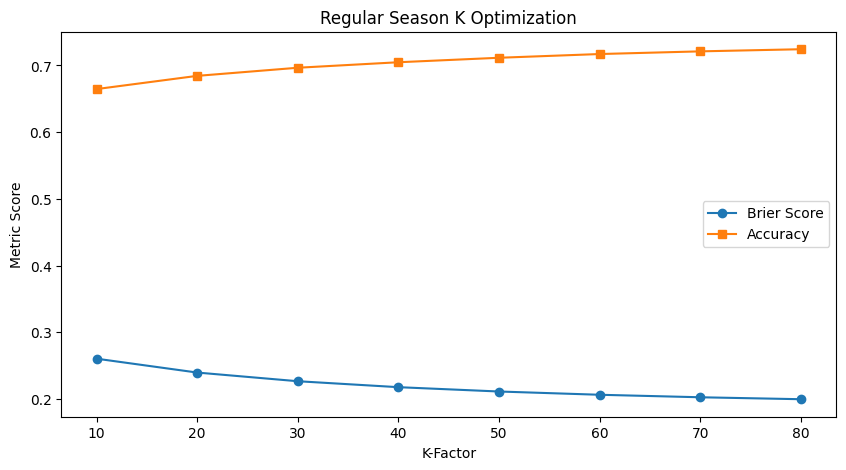

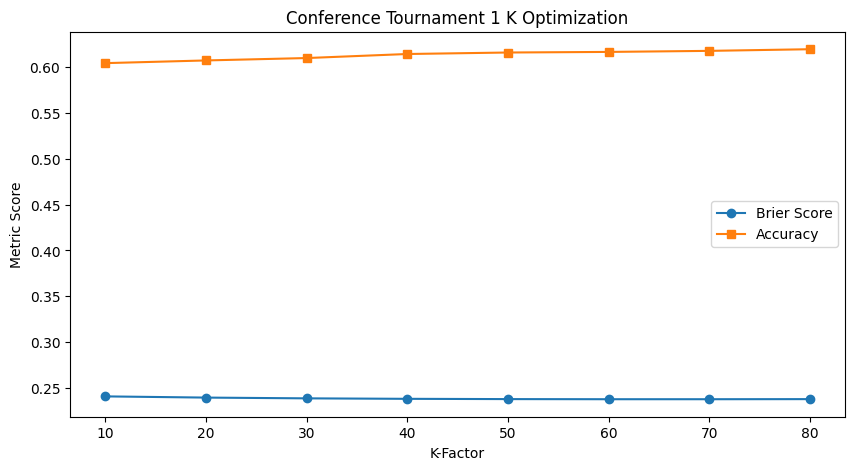

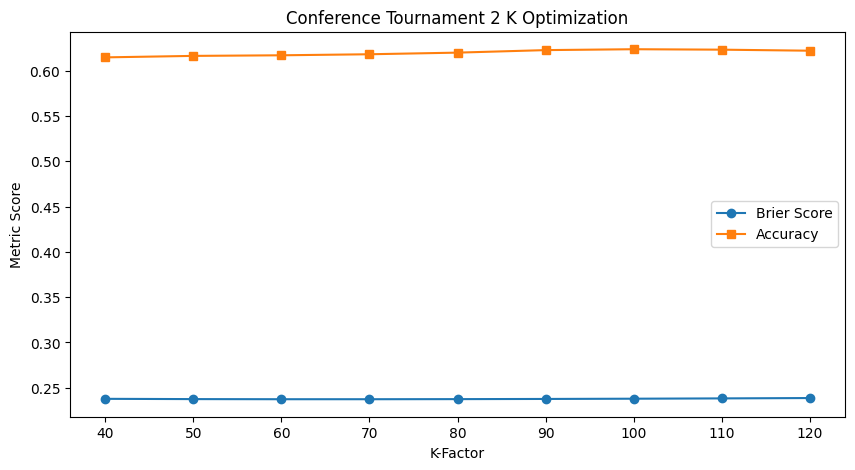

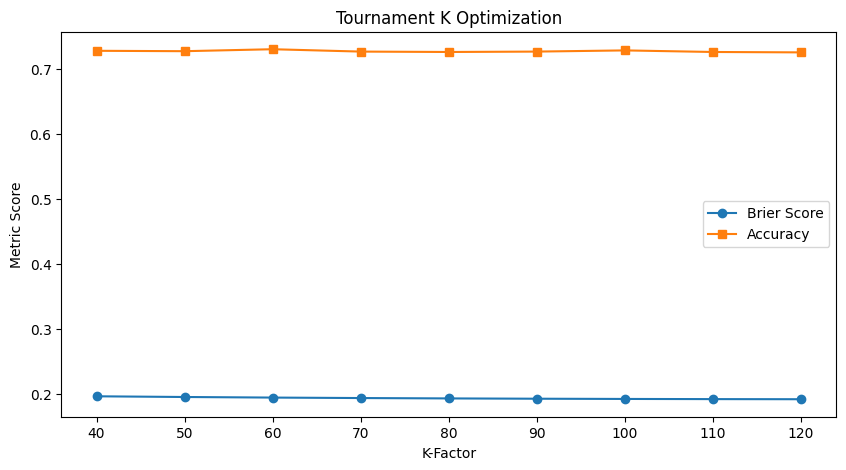

Best Regular Season K: K              80.000000
Brier Score     0.199658
MSE             0.199658
Accuracy        0.724381
Name: 7, dtype: float64
Best Conference Tournament 1 K: K              70.000000
Brier Score     0.237405
MSE             0.237405
Accuracy        0.618012
Name: 6, dtype: float64
Best Conference Tournament 2 K: K              70.000000
Brier Score     0.237405
MSE             0.237405
Accuracy        0.618012
Name: 3, dtype: float64
Best Tournament K: K              120.000000
Brier Score      0.192343
MSE              0.192343
Accuracy         0.725455
Name: 8, dtype: float64


In [49]:
# 📌 CONFIGURATION CONSTANTS
SEASON_START = 1998  # Earliest season to use

# 📌 Load the dataset (expected format: Season, DayNum, Team1, Team2, Score1, Score2, IsTournament, HomeTeam)
# df = pd.read_csv("game_results.csv")  # Replace with your actual dataset
df = game_data_df[game_data_df['gender'] == "Women"]

# 📌 Split Regular Season & Tournament Data
df_reg_season = df[df['Stage'] == 0]
df_conf_tournament = df[df['Stage'] == 1]
df_tournament = df[df['Stage'] == 2]

# 📌 Run experiments
reg_season_results = evaluate_k_values(df_reg_season, K_VALUES)
conf_tournament_1_results = evaluate_k_values(df_conf_tournament, K_VALUES)
conf_tournament_2_results = evaluate_k_values(df_conf_tournament, K_TOURNAMENT_VALUES)
tournament_results = evaluate_k_values(df_tournament, K_TOURNAMENT_VALUES)

# 📌 Plot results
plot_results(reg_season_results, "Regular Season K Optimization")
plot_results(conf_tournament_1_results, "Conference Tournament 1 K Optimization")
plot_results(conf_tournament_2_results, "Conference Tournament 2 K Optimization")
plot_results(tournament_results, "Tournament K Optimization")

# 📌 Find the best K-factor (minimizing Brier Score while maintaining high accuracy)
best_reg_season_k = reg_season_results.sort_values(by=['Brier Score', 'Accuracy'], ascending=[True, False]).iloc[0]
best_conf_tournament_1_k = conf_tournament_1_results.sort_values(by=['Brier Score', 'Accuracy'], ascending=[True, False]).iloc[0]
best_conf_tournament_2_k = conf_tournament_2_results.sort_values(by=['Brier Score', 'Accuracy'], ascending=[True, False]).iloc[0]
best_tournament_k = tournament_results.sort_values(by=['Brier Score', 'Accuracy'], ascending=[True, False]).iloc[0]

print(f"Best Regular Season K: {best_reg_season_k}")
print(f"Best Conference Tournament 1 K: {best_conf_tournament_1_k}")
print(f"Best Conference Tournament 2 K: {best_conf_tournament_2_k}")
print(f"Best Tournament K: {best_tournament_k}")


## Basic Elo Ratings Model